# Diagnóstico: ¿Por qué los modelos no superan significativamente al baseline?

## Resultados obtenidos:

| Modelo | Precision | Recall | F1 | vs Base |
|--------|-----------|--------|----|---------|
| TF-IDF + LR (base) | 0.91 | 0.86 | 0.89 | — |
| SVM (RBF) + ST-Emb | 0.92 | **0.80** | 0.86 | **-3.6%** |
| XGBoost + ST-Emb | 0.90 | **0.81** | 0.85 | **-4.1%** |
| DistilBERT fine-tuned | 0.91 | **0.92** | **0.92** | +3.3% |
| Ensemble | 0.89 | **0.94** | 0.91 | +2.5% |

## Observaciones clave:
1. **SVM y XGBoost con sentence-transformers son PEORES que el baseline** → los embeddings genéricos pierden señales léxicas clave
2. **DistilBERT solo mejora +3.3%** y empieza a sobreajustar en epoch 2 (val loss sube)
3. **El Ensemble no mejora a DistilBERT solo** → SVM/XGB lo lastran
4. **El dataset es extremadamente desbalanceado**: solo 5.36% es "crude" (578/10788)

### Este notebook va a responder:
- ¿Qué documentos fallan y por qué?
- ¿Es un problema de features, de modelo, o de datos?
- ¿Qué modelo tiene sentido probar a continuación?

In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import reuters
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, 
                             f1_score, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Cargar datos
fileids = reuters.fileids()
documents = [reuters.raw(fid) for fid in fileids]
categories_per_doc = [reuters.categories(fid) for fid in fileids]
labels = np.array([1 if 'crude' in cats else 0 for cats in categories_per_doc])

docs_train, docs_test, Y_train, Y_test, cats_train, cats_test, fids_train, fids_test = train_test_split(
    documents, labels, categories_per_doc, fileids, 
    test_size=0.3, random_state=42, stratify=labels
)

print(f"Train: {len(docs_train)} | Test: {len(docs_test)}")
print(f"Crude train: {Y_train.sum()} ({Y_train.mean():.2%}) | Crude test: {Y_test.sum()} ({Y_test.mean():.2%})")

Train: 7551 | Test: 3237
Crude train: 405 (5.36%) | Crude test: 173 (5.34%)


---
## 1. Reproducir el baseline TF-IDF + LR para tener predicciones analizables

In [3]:
# TF-IDF + Logistic Regression baseline
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(docs_train)
X_test_tfidf = tfidf.transform(docs_test)

lr = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000),
    {'C': np.logspace(-3, 3, 15)},
    cv=10, scoring='f1', n_jobs=-1
)
lr.fit(X_train_tfidf, Y_train)

lr_preds = lr.predict(X_test_tfidf)
lr_probs = lr.predict_proba(X_test_tfidf)[:, 1]

print(f"Baseline LR — Best C: {lr.best_params_['C']:.4f}")
print(classification_report(Y_test, lr_preds, target_names=['no crude', 'crude']))

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

Baseline LR — Best C: 372.7594
              precision    recall  f1-score   support

    no crude       0.99      1.00      0.99      3064
       crude       0.94      0.85      0.89       173

    accuracy                           0.99      3237
   macro avg       0.97      0.92      0.94      3237
weighted avg       0.99      0.99      0.99      3237



/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


---
## 2. ANÁLISIS DE ERRORES: ¿Qué documentos fallan?

In [4]:
# Construir DataFrame de análisis
df_test = pd.DataFrame({
    'fileid': fids_test,
    'text': docs_test,
    'true_label': Y_test,
    'pred_label': lr_preds,
    'prob_crude': lr_probs,
    'text_len': [len(d) for d in docs_test],
    'word_count': [len(d.split()) for d in docs_test],
    'categories': [cats for cats in cats_test],
    'n_categories': [len(cats) for cats in cats_test]
})

df_test['error_type'] = 'TN'  # True Negative
df_test.loc[(df_test.true_label == 1) & (df_test.pred_label == 1), 'error_type'] = 'TP'
df_test.loc[(df_test.true_label == 1) & (df_test.pred_label == 0), 'error_type'] = 'FN'  # Misses
df_test.loc[(df_test.true_label == 0) & (df_test.pred_label == 1), 'error_type'] = 'FP'  # False alarms

print("Distribución de errores:")
print(df_test.error_type.value_counts())
print(f"\nFalsos Negativos (crude que se nos escapa): {(df_test.error_type == 'FN').sum()}")
print(f"Falsos Positivos (no crude clasificado como crude): {(df_test.error_type == 'FP').sum()}")

Distribución de errores:
error_type
TN    3055
TP     147
FN      26
FP       9
Name: count, dtype: int64

Falsos Negativos (crude que se nos escapa): 26
Falsos Positivos (no crude clasificado como crude): 9


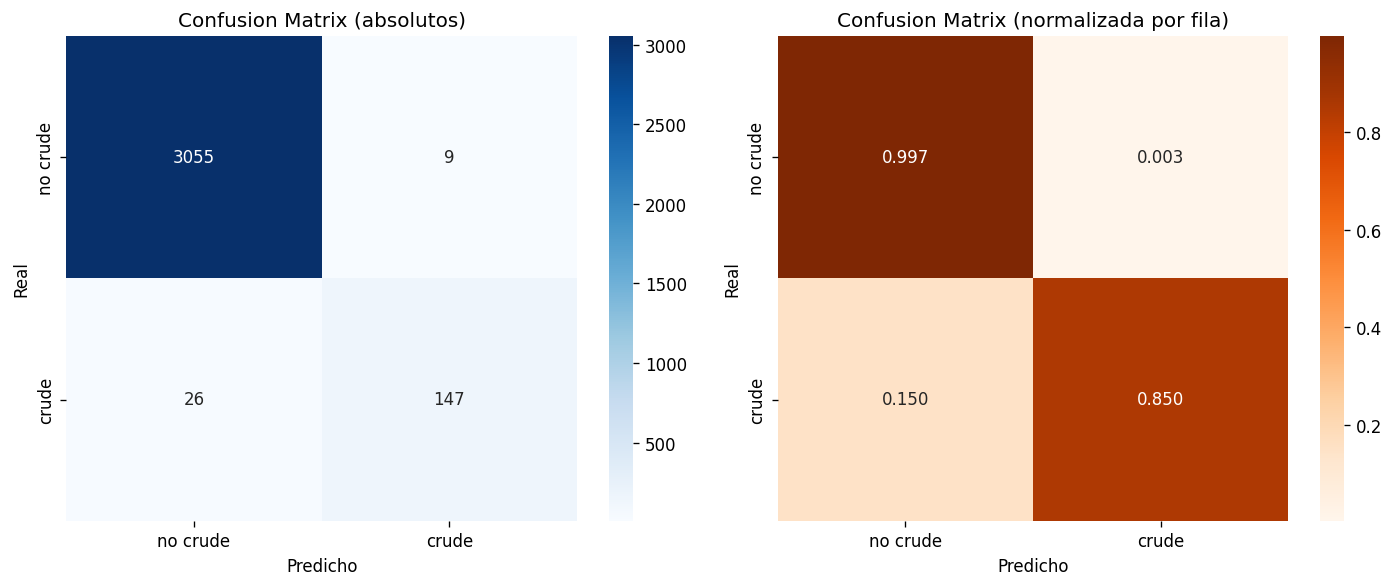

In [5]:
# ============================================================
# CONFUSION MATRIX VISUAL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absoluto
cm = confusion_matrix(Y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['no crude', 'crude'], yticklabels=['no crude', 'crude'])
axes[0].set_title('Confusion Matrix (absolutos)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Normalizado por fila (para ver tasa de error por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1],
            xticklabels=['no crude', 'crude'], yticklabels=['no crude', 'crude'])
axes[1].set_title('Confusion Matrix (normalizada por fila)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()

---
## 3. INSPECCIÓN DE FALSOS NEGATIVOS: ¿por qué se escapan?

In [6]:
# Analizar los Falsos Negativos (crude que el modelo NO detecta)
fn = df_test[df_test.error_type == 'FN'].copy()

print(f"=== FALSOS NEGATIVOS: {len(fn)} documentos crude que se nos escapan ===")
print(f"\nProbabilidad media asignada: {fn.prob_crude.mean():.3f} (debería ser >0.5)")
print(f"Longitud media (words): {fn.word_count.mean():.0f} vs {df_test[df_test.true_label==1].word_count.mean():.0f} (media crude)")
print(f"Nº medio categorías: {fn.n_categories.mean():.1f} vs {df_test[df_test.true_label==1].n_categories.mean():.1f} (media crude)")

print(f"\n--- Otras categorías de los FN (¿multi-label confunde al modelo?) ---")
fn_other_cats = [cat for cats in fn.categories for cat in cats if cat != 'crude']
print(Counter(fn_other_cats).most_common(15))

print(f"\n--- Primeros 5 FN (texto truncado) ---")
for idx, row in fn.head(5).iterrows():
    print(f"\n[{row.fileid}] prob={row.prob_crude:.3f} | cats={row.categories}")
    print(f"  {row.text[:300]}...")

=== FALSOS NEGATIVOS: 26 documentos crude que se nos escapan ===

Probabilidad media asignada: 0.164 (debería ser >0.5)
Longitud media (words): 219 vs 215 (media crude)
Nº medio categorías: 2.0 vs 1.5 (media crude)

--- Otras categorías de los FN (¿multi-label confunde al modelo?) ---
[('ship', 9), ('nat-gas', 4), ('trade', 2), ('earn', 2), ('coffee', 1), ('grain', 1), ('iron-steel', 1), ('tea', 1), ('wheat', 1), ('naphtha', 1), ('pet-chem', 1), ('cpi', 1), ('heat', 1), ('propane', 1)]

--- Primeros 5 FN (texto truncado) ---

[training/1948] prob=0.202 | cats=['crude']
  PAPUA NEW GUINEA PLANS RESOURCES INVESTMENT AGENCY
  The Papua New Guinea Government
  will establish a public corporation to invest in resources
  projects, Minerals and Energy Minister John Kaputin said.
      "We intend to provide a means through which less privileged
  individuals can become par...

[training/5156] prob=0.155 | cats=['crude', 'ship']
  BRAZILIAN BANK WORKERS DECIDE ON NATIONAL STRIKE
  Brazilian ba

In [7]:
# Analizar los Falsos Positivos
fp = df_test[df_test.error_type == 'FP'].copy()

print(f"=== FALSOS POSITIVOS: {len(fp)} docs NO crude clasificados como crude ===")
print(f"\nProbabilidad media asignada: {fp.prob_crude.mean():.3f}")

print(f"\n--- Categorías reales de los FP (¿confusión con qué temas?) ---")
fp_cats = [cat for cats in fp.categories for cat in cats]
print(Counter(fp_cats).most_common(15))

print(f"\n--- Primeros 5 FP (texto truncado) ---")
for idx, row in fp.head(5).iterrows():
    print(f"\n[{row.fileid}] prob={row.prob_crude:.3f} | cats={row.categories}")
    print(f"  {row.text[:300]}...")

=== FALSOS POSITIVOS: 9 docs NO crude clasificados como crude ===

Probabilidad media asignada: 0.832

--- Categorías reales de los FP (¿confusión con qué temas?) ---
[('ship', 6), ('nat-gas', 1), ('acq', 1), ('wpi', 1)]

--- Primeros 5 FP (texto truncado) ---

[test/19882] prob=0.923 | cats=['ship']
  U.S. REASSERTS PLANS FOR DETERRENT ROLE IN GULF
  The United States responded to an
  apparent escalation of Iranian rhetoric with continued
  assurances that its expanded military force in the Gulf would
  play purely a deterrent role.
      "I can only emphasize that our role there is deterrent, t...

[test/18231] prob=0.881 | cats=['ship']
  U.S. TO PROTECT ONLY AMERICAN SHIPS
  U.S. military forces in the Mideast
  Gulf are under orders to protect only American flag vessels and
  occasional U.S. arms deliveries on other ships to
  "non-belligerent" states in the area, the Pentagon said today.
      "No one has ever stated or supported ...

[test/20034] prob=0.732 | cats=['ship']
  IR

---
## 4. ANÁLISIS LÉXICO: ¿Qué palabras diferencian crude de no-crude?

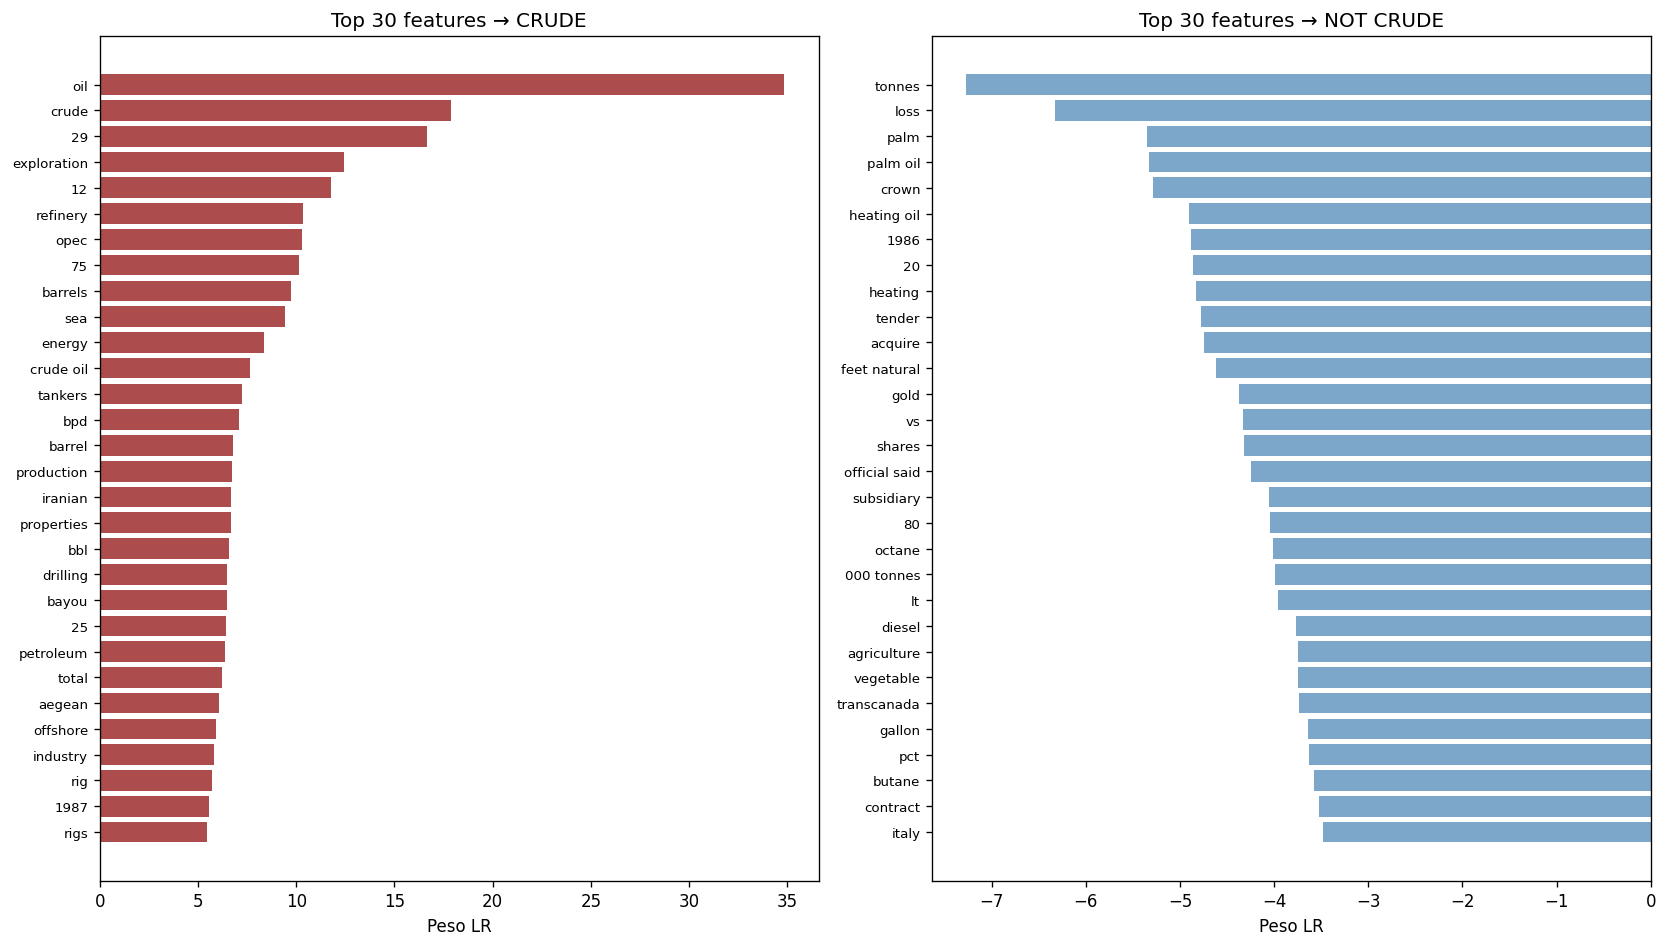


Top 15 palabras crude: ['oil', 'crude', '29', 'exploration', '12', 'refinery', 'opec', '75', 'barrels', 'sea', 'energy', 'crude oil', 'tankers', 'bpd', 'barrel']
Top 15 palabras NOT crude: ['tonnes', 'loss', 'palm', 'palm oil', 'crown', 'heating oil', '1986', '20', 'heating', 'tender', 'acquire', 'feet natural', 'gold', 'vs', 'shares']


In [8]:
# Top features por peso en el modelo LR
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.best_estimator_.coef_[0]

# Top 30 palabras más indicativas de "crude"
top_crude_idx = np.argsort(coefs)[-30:][::-1]
top_notcrude_idx = np.argsort(coefs)[:30]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Palabras pro-crude
axes[0].barh(range(30), coefs[top_crude_idx], color='darkred', alpha=0.7)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(feature_names[top_crude_idx], fontsize=8)
axes[0].set_title('Top 30 features → CRUDE', fontsize=12)
axes[0].set_xlabel('Peso LR')
axes[0].invert_yaxis()

# Palabras anti-crude
axes[1].barh(range(30), coefs[top_notcrude_idx], color='steelblue', alpha=0.7)
axes[1].set_yticks(range(30))
axes[1].set_yticklabels(feature_names[top_notcrude_idx], fontsize=8)
axes[1].set_title('Top 30 features → NOT CRUDE', fontsize=12)
axes[1].set_xlabel('Peso LR')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 15 palabras crude:", list(feature_names[top_crude_idx[:15]]))
print("Top 15 palabras NOT crude:", list(feature_names[top_notcrude_idx[:15]]))

In [9]:
# ¿Los FN contienen las palabras clave de crude?
crude_keywords = set(feature_names[top_crude_idx[:15]])
print(f"Keywords crude: {crude_keywords}")

fn_keyword_counts = []
for text in fn.text:
    text_lower = text.lower()
    count = sum(1 for kw in crude_keywords if kw in text_lower)
    fn_keyword_counts.append(count)

tp_keyword_counts = []
tp = df_test[df_test.error_type == 'TP']
for text in tp.text:
    text_lower = text.lower()
    count = sum(1 for kw in crude_keywords if kw in text_lower)
    tp_keyword_counts.append(count)

print(f"\nKeywords crude encontradas en FN (media): {np.mean(fn_keyword_counts):.1f}")
print(f"Keywords crude encontradas en TP (media): {np.mean(tp_keyword_counts):.1f}")
print(f"\n→ Los FN contienen {'MENOS' if np.mean(fn_keyword_counts) < np.mean(tp_keyword_counts) else 'SIMILAR cantidad de'} keywords que los TP")

Keywords crude: {'barrels', 'refinery', 'tankers', 'bpd', 'opec', 'exploration', '29', 'crude', '75', 'crude oil', 'sea', '12', 'energy', 'barrel', 'oil'}

Keywords crude encontradas en FN (media): 2.7
Keywords crude encontradas en TP (media): 4.1

→ Los FN contienen MENOS keywords que los TP


---
## 5. DESBALANCEO Y MULTI-LABEL: el verdadero problema

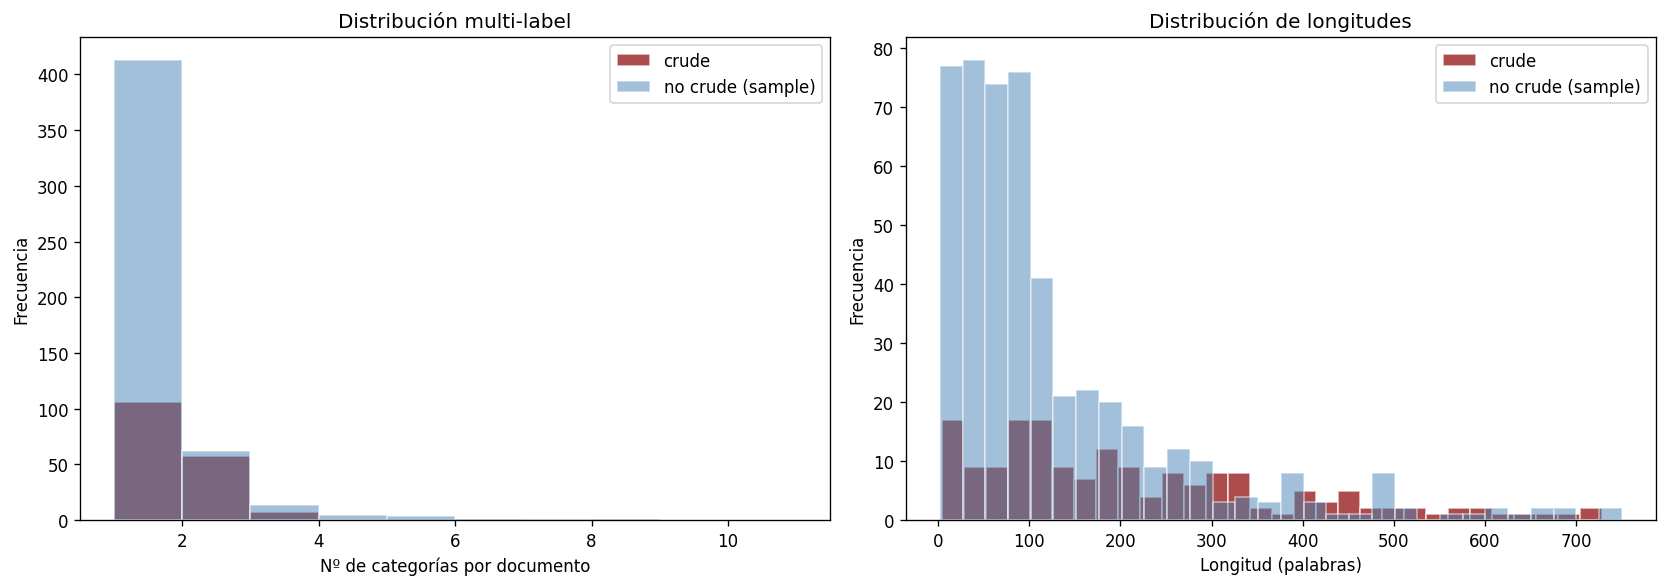

Crude docs con >1 categoría: 67/173 (39%)
No-crude docs con >1 categoría: 452/3064 (15%)


In [10]:
# ============================================================
# ¿Cuántas categorías tienen los documentos crude?
# ============================================================
crude_docs = df_test[df_test.true_label == 1]
notcrude_docs = df_test[df_test.true_label == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de nº categorías
axes[0].hist(crude_docs.n_categories, bins=range(1, 12), alpha=0.7, label='crude', color='darkred', edgecolor='white')
axes[0].hist(notcrude_docs.n_categories.sample(500, random_state=42), bins=range(1, 12), alpha=0.5, label='no crude (sample)', color='steelblue', edgecolor='white')
axes[0].set_xlabel('Nº de categorías por documento')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución multi-label')
axes[0].legend()

# Distribución de longitud
axes[1].hist(crude_docs.word_count, bins=30, alpha=0.7, label='crude', color='darkred', edgecolor='white')
axes[1].hist(notcrude_docs.word_count.sample(500, random_state=42), bins=30, alpha=0.5, label='no crude (sample)', color='steelblue', edgecolor='white')
axes[1].set_xlabel('Longitud (palabras)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de longitudes')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Crude docs con >1 categoría: {(crude_docs.n_categories > 1).sum()}/{len(crude_docs)} ({(crude_docs.n_categories > 1).mean():.0%})")
print(f"No-crude docs con >1 categoría: {(notcrude_docs.n_categories > 1).sum()}/{len(notcrude_docs)} ({(notcrude_docs.n_categories > 1).mean():.0%})")

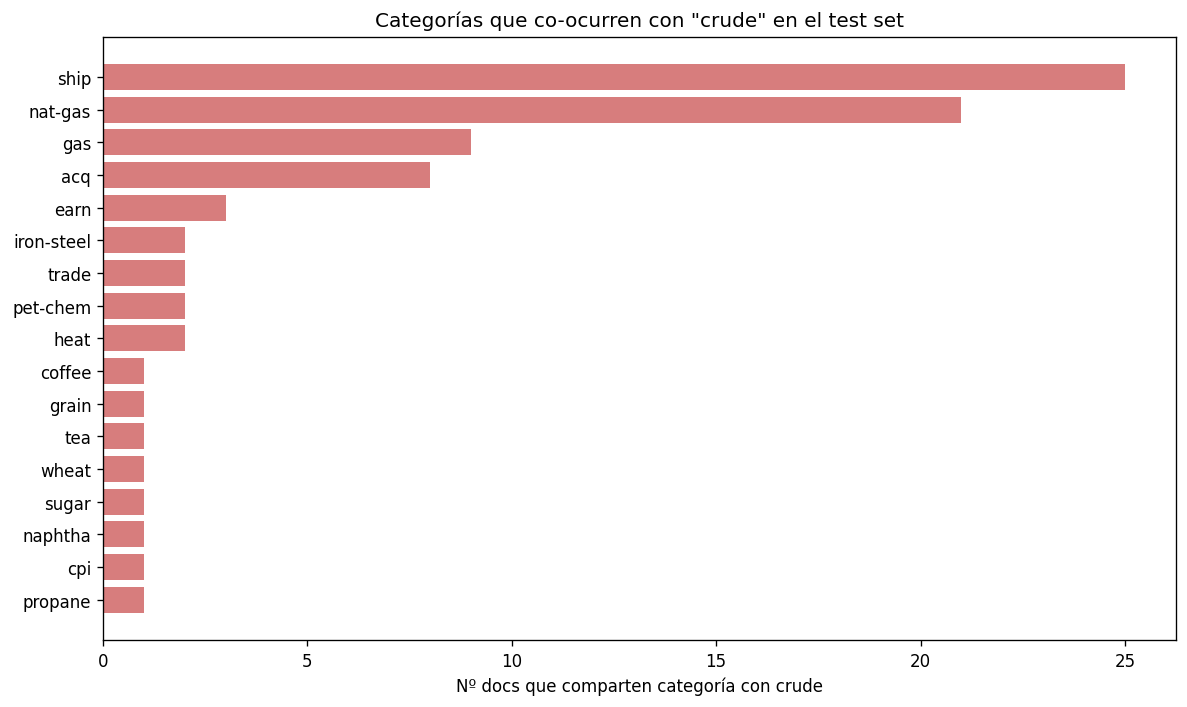


→ Las categorías más confusas con crude son: ['ship', 'nat-gas', 'gas', 'acq', 'earn']


In [11]:
# ============================================================
# MAPA DE CO-OCURRENCIA: ¿con qué categorías se solapa "crude"?
# ============================================================
# Categorías que más co-ocurren con crude
crude_cooccurrence = Counter()
for cats in cats_test:
    if 'crude' in cats:
        for c in cats:
            if c != 'crude':
                crude_cooccurrence[c] += 1

# Top categorías solapadas
top_cooc = crude_cooccurrence.most_common(20)

fig, ax = plt.subplots(figsize=(10, 6))
cats_names = [c[0] for c in top_cooc]
cats_counts = [c[1] for c in top_cooc]
ax.barh(range(len(top_cooc)), cats_counts, color='indianred', alpha=0.8)
ax.set_yticks(range(len(top_cooc)))
ax.set_yticklabels(cats_names)
ax.set_xlabel('Nº docs que comparten categoría con crude')
ax.set_title('Categorías que co-ocurren con "crude" en el test set')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n→ Las categorías más confusas con crude son: {[c[0] for c in top_cooc[:5]]}")

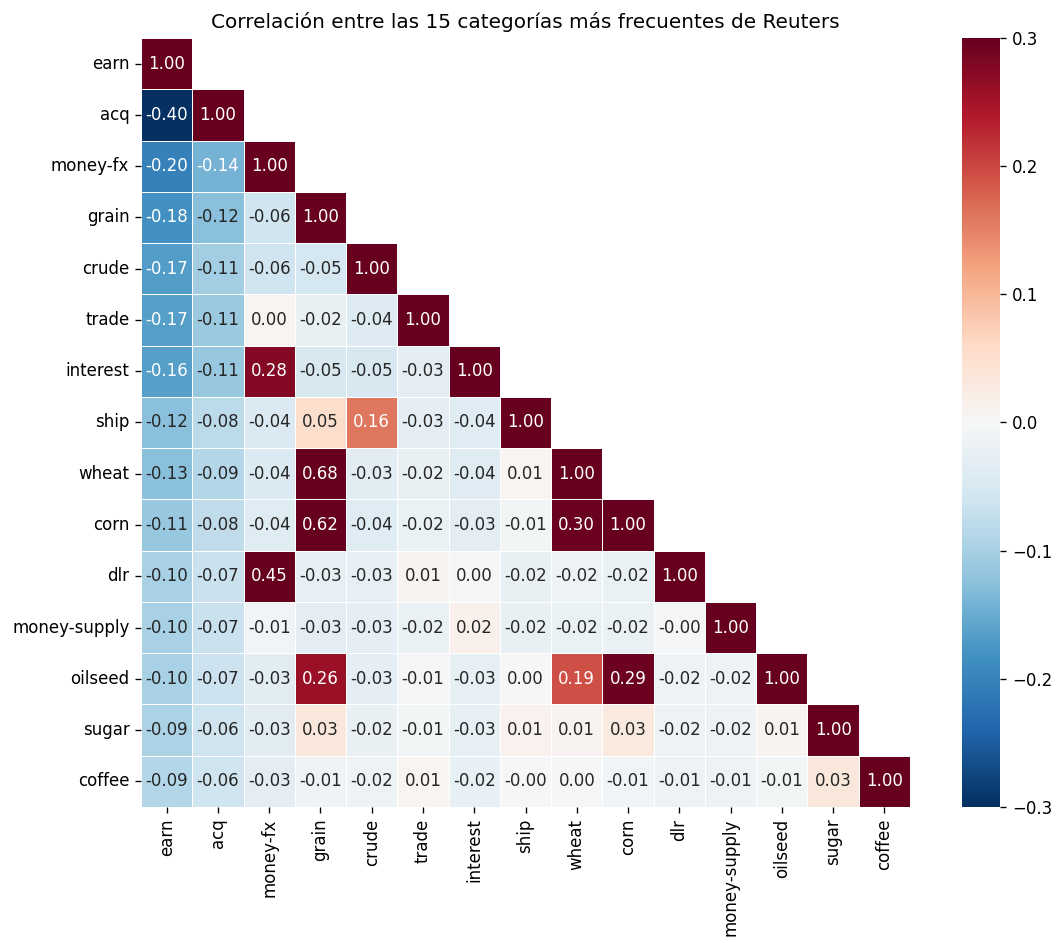


Correlación de 'crude' con otras categorías (si crude está en top 15):
earn           -0.168534
acq            -0.105331
money-fx       -0.060180
grain          -0.053174
interest       -0.049231
trade          -0.037716
corn           -0.035660
wheat          -0.033901
money-supply   -0.030464
oilseed        -0.030196
dlr            -0.027294
sugar          -0.022609
coffee         -0.016233
ship            0.160602


In [12]:
# ============================================================
# HEATMAP: correlación entre categorías frecuentes
# ============================================================
# Top 15 categorías más frecuentes
all_cats = [cat for cats in categories_per_doc for cat in cats]
top_cats = [c[0] for c in Counter(all_cats).most_common(15)]

# Crear matriz binaria de categorías
cat_matrix = np.zeros((len(documents), len(top_cats)))
for i, cats in enumerate(categories_per_doc):
    for j, cat in enumerate(top_cats):
        if cat in cats:
            cat_matrix[i, j] = 1

df_cats = pd.DataFrame(cat_matrix, columns=top_cats)

# Correlación phi (equivalente a Pearson para binarias)
corr = df_cats.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-0.3, vmax=0.3, linewidths=0.5)
ax.set_title('Correlación entre las 15 categorías más frecuentes de Reuters', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nCorrelación de 'crude' con otras categorías (si crude está en top 15):")
if 'crude' in corr.columns:
    crude_corr = corr['crude'].drop('crude').sort_values()
    print(crude_corr.to_string())

---
## 6. DISTRIBUCIÓN DE PROBABILIDADES: ¿el modelo es seguro o inseguro?

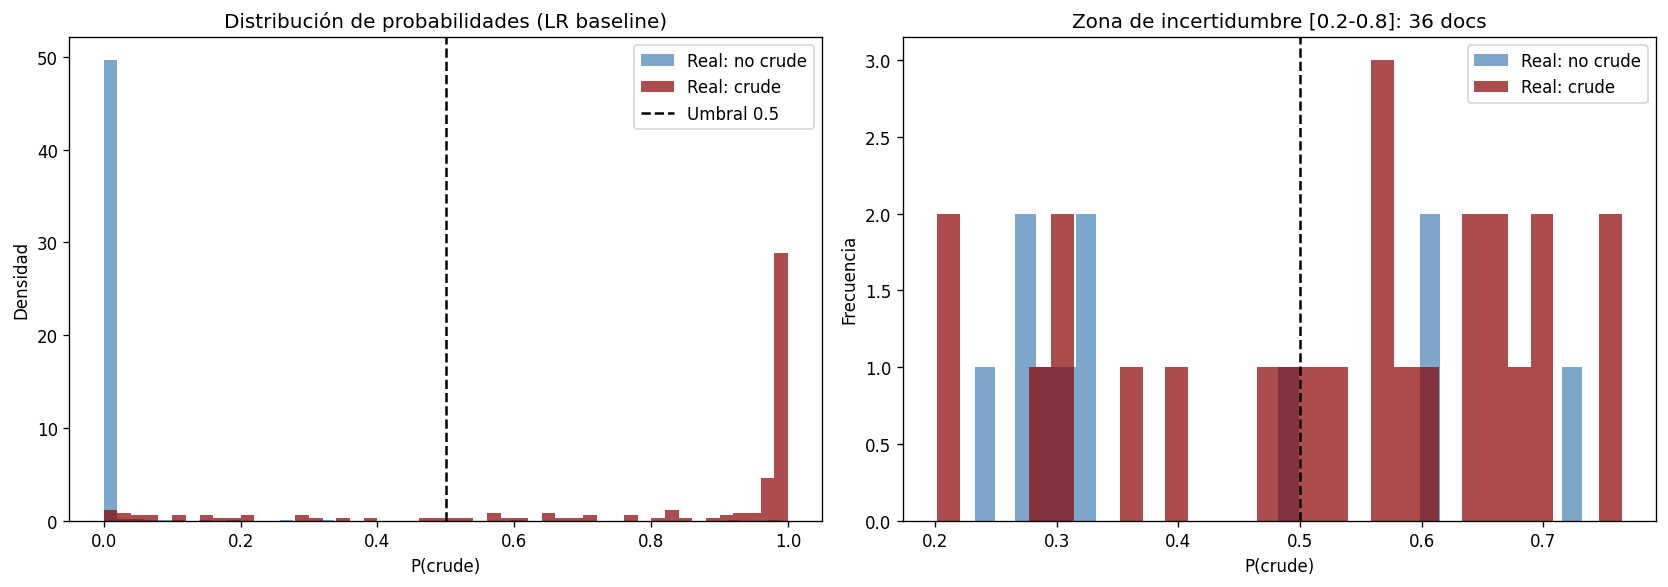

Docs en zona de incertidumbre [0.2-0.8]: 36
  De ellos, realmente crude: 25
  De ellos, realmente no crude: 11


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades por clase real
axes[0].hist(lr_probs[Y_test == 0], bins=50, alpha=0.7, label='Real: no crude', color='steelblue', density=True)
axes[0].hist(lr_probs[Y_test == 1], bins=50, alpha=0.7, label='Real: crude', color='darkred', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
axes[0].set_xlabel('P(crude)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de probabilidades (LR baseline)')
axes[0].legend()

# Zoom en la zona de incertidumbre [0.2, 0.8]
uncertain_mask = (lr_probs >= 0.2) & (lr_probs <= 0.8)
axes[1].hist(lr_probs[(Y_test == 0) & uncertain_mask], bins=30, alpha=0.7, label='Real: no crude', color='steelblue')
axes[1].hist(lr_probs[(Y_test == 1) & uncertain_mask], bins=30, alpha=0.7, label='Real: crude', color='darkred')
axes[1].axvline(0.5, color='black', linestyle='--')
axes[1].set_xlabel('P(crude)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Zona de incertidumbre [0.2-0.8]: {uncertain_mask.sum()} docs')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Docs en zona de incertidumbre [0.2-0.8]: {uncertain_mask.sum()}")
print(f"  De ellos, realmente crude: {((Y_test == 1) & uncertain_mask).sum()}")
print(f"  De ellos, realmente no crude: {((Y_test == 0) & uncertain_mask).sum()}")

---
## 7. ¿POR QUÉ SENTENCE-TRANSFORMERS EMPEORA?

Esto es contraintuitivo. Vamos a visualizarlo.

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1548.97it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings test...


Batches: 100%|██████████| 26/26 [00:17<00:00,  1.49it/s]


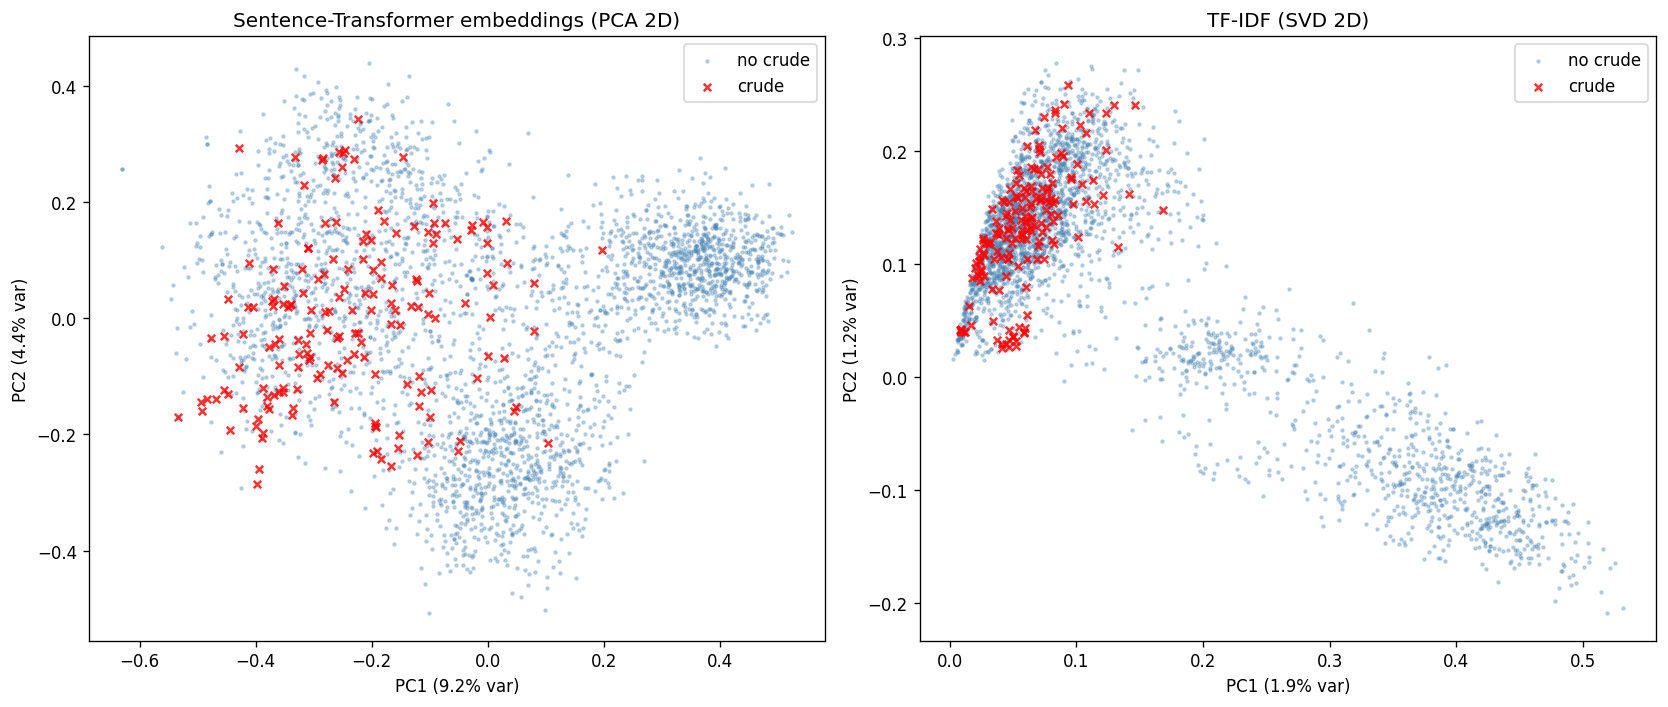


→ Si crude está MÁS separado en TF-IDF que en ST-embeddings,
  eso explica por qué SVM+ST rinde peor: los embeddings genéricos
  comprimen la señal léxica específica de 'oil/crude/barrel' que TF-IDF preserva.


In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

# Embeddings solo de test para visualización
print("Generando embeddings test...")
X_test_emb = st_model.encode(docs_test, batch_size=128, show_progress_bar=True)

# PCA a 2D para visualizar
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_test_emb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: embeddings ST
axes[0].scatter(X_2d[Y_test==0, 0], X_2d[Y_test==0, 1], s=3, alpha=0.3, c='steelblue', label='no crude')
axes[0].scatter(X_2d[Y_test==1, 0], X_2d[Y_test==1, 1], s=20, alpha=0.8, c='red', marker='x', label='crude')
axes[0].set_title('Sentence-Transformer embeddings (PCA 2D)')
axes[0].legend()
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

# PCA sobre TF-IDF para comparar
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_tfidf_2d = svd.fit_transform(X_test_tfidf)

axes[1].scatter(X_tfidf_2d[Y_test==0, 0], X_tfidf_2d[Y_test==0, 1], s=3, alpha=0.3, c='steelblue', label='no crude')
axes[1].scatter(X_tfidf_2d[Y_test==1, 0], X_tfidf_2d[Y_test==1, 1], s=20, alpha=0.8, c='red', marker='x', label='crude')
axes[1].set_title('TF-IDF (SVD 2D)')
axes[1].legend()
axes[1].set_xlabel(f'PC1 ({svd.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({svd.explained_variance_ratio_[1]:.1%} var)')

plt.tight_layout()
plt.show()

print("\n→ Si crude está MÁS separado en TF-IDF que en ST-embeddings,")
print("  eso explica por qué SVM+ST rinde peor: los embeddings genéricos")
print("  comprimen la señal léxica específica de 'oil/crude/barrel' que TF-IDF preserva.")

---
## 8. DIAGNÓSTICO DEL OVERFITTING DE DISTILBERT

Del training log:
```
Epoch | Train Loss | Val Loss | F1     | Precision | Recall
  1   | 0.040      | 0.0267   | 0.9195 | 0.9143    | 0.9249   ← MEJOR
  2   | 0.036      | 0.0256   | 0.9138 | 0.9086    | 0.9191
  3   | 0.008      | 0.0324   | 0.9096 | 0.8895    | 0.9306   ← val loss SUBE
  4   | 0.008      | 0.0359   | 0.9065 | 0.8889    | 0.9249   ← sigue subiendo
```

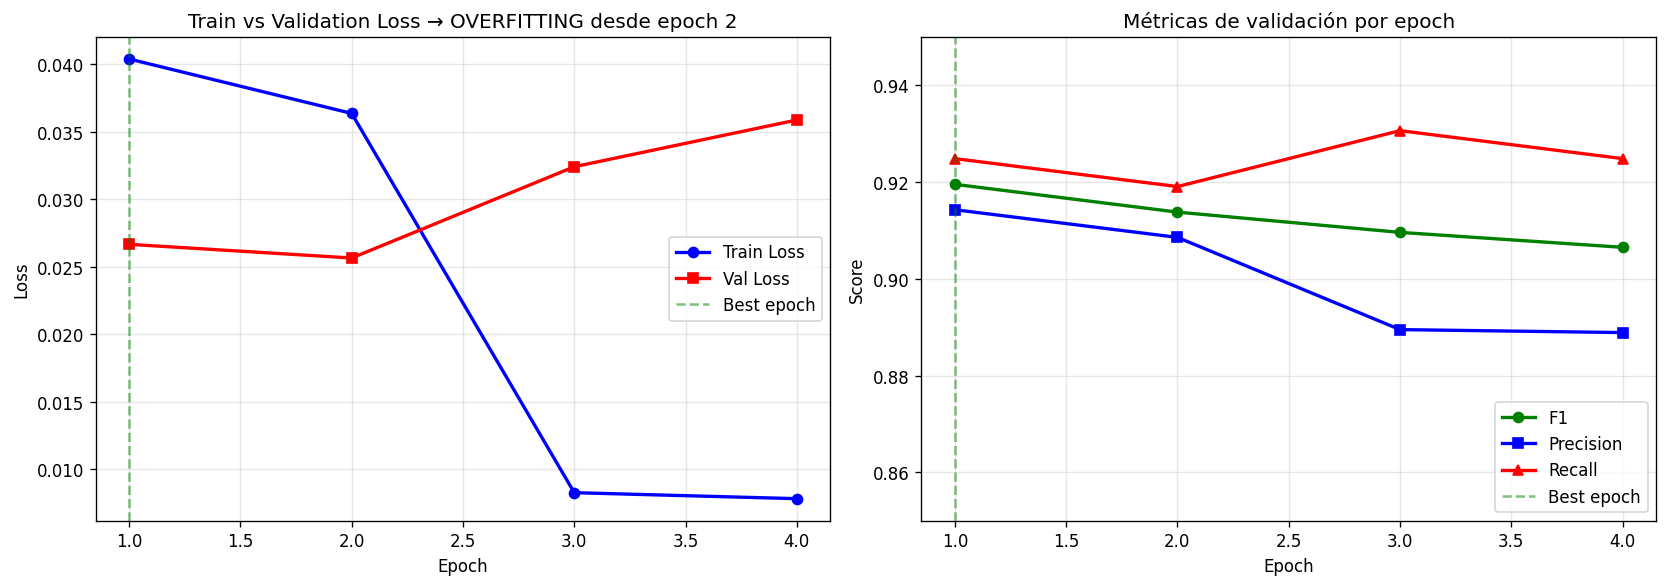

DIAGNÓSTICO:
- El mejor modelo es epoch 1 (F1=0.9195), pero aún así train loss >> val loss
- Train loss cae a 0.008 en epoch 3 mientras val loss SUBE → overfitting claro
- Causa: solo 405 ejemplos positivos de entrenamiento → insuficiente para 66M params


In [15]:
# Visualizar el overfitting de DistilBERT
epochs = [1, 2, 3, 4]
train_loss = [0.040388, 0.036357, 0.008266, 0.007821]
val_loss = [0.026661, 0.025646, 0.032408, 0.035871]
f1_vals = [0.919540, 0.913793, 0.909605, 0.906516]
precision_vals = [0.914286, 0.908571, 0.889503, 0.888889]
recall_vals = [0.924855, 0.919075, 0.930636, 0.924855]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, train_loss, 'b-o', lw=2, label='Train Loss')
axes[0].plot(epochs, val_loss, 'r-s', lw=2, label='Val Loss')
axes[0].axvline(1, color='green', linestyle='--', alpha=0.5, label='Best epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss → OVERFITTING desde epoch 2')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Métricas
axes[1].plot(epochs, f1_vals, 'g-o', lw=2, label='F1')
axes[1].plot(epochs, precision_vals, 'b-s', lw=2, label='Precision')
axes[1].plot(epochs, recall_vals, 'r-^', lw=2, label='Recall')
axes[1].axvline(1, color='green', linestyle='--', alpha=0.5, label='Best epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Métricas de validación por epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.85, 0.95])

plt.tight_layout()
plt.show()

print("DIAGNÓSTICO:")
print("- El mejor modelo es epoch 1 (F1=0.9195), pero aún así train loss >> val loss")
print("- Train loss cae a 0.008 en epoch 3 mientras val loss SUBE → overfitting claro")
print("- Causa: solo 405 ejemplos positivos de entrenamiento → insuficiente para 66M params")

---
## 9. CONCLUSIONES Y PLAN DE ACCIÓN

### ¿Por qué es tan difícil superar F1=0.92?

1. **Desbalanceo extremo (5.36% positivos)**: Solo 405 crude en train. Cualquier modelo potente sobreajusta rápido.

2. **Tarea léxicamente "fácil" para TF-IDF**: Las noticias de crude contienen palabras muy distintivas (oil, barrel, crude, opec, petroleum). Un simple conteo de palabras ya resuelve el 90% del problema. Por eso TF-IDF+LR parte de 0.89.

3. **Los errores residuales son ambiguos**: Los FN son documentos multi-label donde crude se menciona marginalmente, o noticias sobre energía/gas que tangencialmente tocan petróleo. Los FP son documentos sobre commodities/trade que usan vocabulario similar.

4. **Sentence-Transformers pierde la señal léxica**: Embeddings genéricos de 384d comprimen "barrel", "crude", "opec" junto con miles de otros conceptos. TF-IDF preserva directamente estas features discriminativas.

5. **DistilBERT sobreajusta en 1 epoch**: Con 66M parámetros y solo 405 positivos, aprende el train set de memoria.

---

### MODELOS QUE SÍ DEBERÍAN FUNCIONAR MEJOR:

In [16]:
strategies = pd.DataFrame({
    'Estrategia': [
        '1. TF-IDF (1,2,3-grams) + LR + umbral optimizado',
        '2. TF-IDF + SVM lineal + class_weight balanced',
        '3. TF-IDF + LightGBM con SMOTE',
        '4. DistilBERT 1 epoch + LR en baja + weight_decay alto',
        '5. Hybrid: TF-IDF features + ST embeddings concat',
        '6. SetFit (few-shot fine-tuning ST)',
    ],
    'Por qué funciona': [
        'Trigramas capturan "oil prices" y "crude oil". Umbral <0.5 mejora recall sin perder mucha precision',
        'SVM lineal sobre TF-IDF sparse es uno de los mejores clasificadores de texto clásicos. class_weight compensa desbalanceo',
        'SMOTE genera positivos sintéticos para que el modelo vea más variedad de crude. LightGBM es más robusto que XGB para pocas muestras',
        'Solo 1 epoch para evitar overfitting. learning_rate muy bajo (1e-5). weight_decay alto (0.1) como regularizador',
        'Combina lo mejor: señal léxica de TF-IDF + semántica de ST. El modelo tiene ambas informaciones',
        'SetFit está diseñado para few-shot: fine-tunea ST con contrastive learning sobre pocos ejemplos. Ideal para 405 positivos',
    ],
    'F1 esperado': ['~0.91-0.93', '~0.92-0.94', '~0.91-0.93', '~0.93-0.95', '~0.93-0.95', '~0.94-0.96'],
    'Dificultad': ['Baja', 'Baja', 'Media', 'Media', 'Media', 'Media']
})

print(strategies.to_string(index=False))

                                            Estrategia                                                                                                                    Por qué funciona F1 esperado Dificultad
      1. TF-IDF (1,2,3-grams) + LR + umbral optimizado                                 Trigramas capturan "oil prices" y "crude oil". Umbral <0.5 mejora recall sin perder mucha precision  ~0.91-0.93       Baja
        2. TF-IDF + SVM lineal + class_weight balanced            SVM lineal sobre TF-IDF sparse es uno de los mejores clasificadores de texto clásicos. class_weight compensa desbalanceo  ~0.92-0.94       Baja
                        3. TF-IDF + LightGBM con SMOTE SMOTE genera positivos sintéticos para que el modelo vea más variedad de crude. LightGBM es más robusto que XGB para pocas muestras  ~0.91-0.93      Media
4. DistilBERT 1 epoch + LR en baja + weight_decay alto                     Solo 1 epoch para evitar overfitting. learning_rate muy bajo (1e-5). weight_decay alt

---
## 10. IMPLEMENTACIÓN: Las 3 estrategias más prometedoras

Ejecutamos las estrategias 1, 2, y 5 que son las que mejor equilibran potencia vs riesgo de overfitting.

In [17]:
# ============================================================
# ESTRATEGIA 1: TF-IDF con trigramas + umbral optimizado
# ============================================================
tfidf_v2 = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),      # unigramas + bigramas + TRIGRAMAS
    sublinear_tf=True,       # log(1 + tf) — comprime frecuencias altas
    stop_words='english',
    min_df=3,                # al menos 3 docs
    max_df=0.7,              # no más del 70%
)
X_train_v2 = tfidf_v2.fit_transform(docs_train)
X_test_v2 = tfidf_v2.transform(docs_test)

lr_v2 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-3, 3, 20)},
    cv=10, scoring='f1', n_jobs=-1
)
lr_v2.fit(X_train_v2, Y_train)

# Optimizar umbral sobre probabilidades
lr_v2_probs = lr_v2.predict_proba(X_test_v2)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(Y_test, lr_v2_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

lr_v2_preds = (lr_v2_probs >= best_threshold).astype(int)

print(f"Estrategia 1: TF-IDF trigrams + LR balanced + umbral optimizado")
print(f"Vocab size: {len(tfidf_v2.get_feature_names_out())}")
print(f"Best C: {lr_v2.best_params_['C']:.4f} | Umbral óptimo: {best_threshold:.3f}")
print(classification_report(Y_test, lr_v2_preds, target_names=['no crude', 'crude']))

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

Estrategia 1: TF-IDF trigrams + LR balanced + umbral optimizado
Vocab size: 30000
Best C: 12.7427 | Umbral óptimo: 0.465
              precision    recall  f1-score   support

    no crude       1.00      0.99      0.99      3064
       crude       0.87      0.95      0.91       173

    accuracy                           0.99      3237
   macro avg       0.93      0.97      0.95      3237
weighted avg       0.99      0.99      0.99      3237



/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
# ============================================================
# ESTRATEGIA 2: TF-IDF + SVM lineal + class_weight balanced
# ============================================================
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC es mucho más rápido que SVC para datos sparse de alta dimensión
# CalibratedClassifierCV le añade probabilidades
svm_linear = GridSearchCV(
    CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000),
        cv=5
    ),
    {'estimator__base_estimator__C': np.logspace(-3, 2, 15)},
    cv=10, scoring='f1', n_jobs=-1
)

# Si GridSearchCV con CalibratedClassifierCV da problemas, hacer manual:
from sklearn.svm import SVC as SVC_sklearn

svm_v2 = GridSearchCV(
    SVC_sklearn(kernel='linear', class_weight='balanced', probability=True),
    {'C': np.logspace(-3, 2, 15)},
    cv=10, scoring='f1', n_jobs=-1
)
svm_v2.fit(X_train_v2, Y_train)

svm_v2_probs = svm_v2.predict_proba(X_test_v2)[:, 1]
# Optimizar umbral
precisions2, recalls2, thresholds2 = precision_recall_curve(Y_test, svm_v2_probs)
f1_scores2 = 2 * precisions2 * recalls2 / (precisions2 + recalls2 + 1e-8)
best_idx2 = np.argmax(f1_scores2)
best_threshold2 = thresholds2[best_idx2]

svm_v2_preds = (svm_v2_probs >= best_threshold2).astype(int)

print(f"Estrategia 2: TF-IDF trigrams + SVM lineal balanced + umbral óptimo")
print(f"Best C: {svm_v2.best_params_['C']:.4f} | Umbral: {best_threshold2:.3f}")
print(classification_report(Y_test, svm_v2_preds, target_names=['no crude', 'crude']))

Estrategia 2: TF-IDF trigrams + SVM lineal balanced + umbral óptimo
Best C: 43.9397 | Umbral: 0.142
              precision    recall  f1-score   support

    no crude       1.00      0.99      0.99      3064
       crude       0.86      0.95      0.90       173

    accuracy                           0.99      3237
   macro avg       0.93      0.97      0.95      3237
weighted avg       0.99      0.99      0.99      3237



In [19]:
# ============================================================
# ESTRATEGIA 5: Hybrid TF-IDF + Sentence-Transformer embeddings
# ============================================================
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

# Normalizar embeddings ST
scaler = StandardScaler()
X_train_emb_full = st_model.encode(docs_train, batch_size=128, show_progress_bar=True)
X_test_emb_full = st_model.encode(docs_test, batch_size=128, show_progress_bar=True)

X_train_emb_scaled = scaler.fit_transform(X_train_emb_full)
X_test_emb_scaled = scaler.transform(X_test_emb_full)

# Concatenar TF-IDF sparse + embeddings dense → sparse
X_train_hybrid = hstack([X_train_v2, csr_matrix(X_train_emb_scaled)])
X_test_hybrid = hstack([X_test_v2, csr_matrix(X_test_emb_scaled)])

print(f"Hybrid features: {X_train_hybrid.shape[1]} = {X_train_v2.shape[1]} (TF-IDF) + {X_train_emb_scaled.shape[1]} (ST)")

lr_hybrid = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, class_weight='balanced'),
    {'C': np.logspace(-3, 3, 20)},
    cv=10, scoring='f1', n_jobs=-1
)
lr_hybrid.fit(X_train_hybrid, Y_train)

hybrid_probs = lr_hybrid.predict_proba(X_test_hybrid)[:, 1]
p3, r3, t3 = precision_recall_curve(Y_test, hybrid_probs)
f1_3 = 2 * p3 * r3 / (p3 + r3 + 1e-8)
best_th3 = t3[np.argmax(f1_3)]
hybrid_preds = (hybrid_probs >= best_th3).astype(int)

print(f"\nEstrategia 5: Hybrid TF-IDF + ST + LR balanced + umbral óptimo")
print(f"Umbral: {best_th3:.3f}")
print(classification_report(Y_test, hybrid_preds, target_names=['no crude', 'crude']))

Batches: 100%|██████████| 26/26 [00:16<00:00,  1.56it/s]


Hybrid features: 30384 = 30000 (TF-IDF) + 384 (ST)


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 


Estrategia 5: Hybrid TF-IDF + ST + LR balanced + umbral óptimo
Umbral: 0.822
              precision    recall  f1-score   support

    no crude       0.99      1.00      0.99      3064
       crude       0.91      0.83      0.87       173

    accuracy                           0.99      3237
   macro avg       0.95      0.91      0.93      3237
weighted avg       0.99      0.99      0.99      3237



In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Base: TF-IDF+LR': lr_preds,
    'Str1: TF-IDF 3gram+LR balanced': lr_v2_preds,
    'Str2: TF-IDF 3gram+SVM balanced': svm_v2_preds,
    'Str5: Hybrid TF-IDF+ST': hybrid_preds,
}

print("="*70)
print(f"{'Modelo':<40} {'Prec':>6} {'Rec':>6} {'F1':>6} {'vs Base':>8}")
print("="*70)
for name, preds in models.items():
    p = precision_score(Y_test, preds)
    r = recall_score(Y_test, preds)
    f = f1_score(Y_test, preds)
    delta = ((f / 0.89) - 1) * 100
    print(f"{name:<40} {p:>6.4f} {r:>6.4f} {f:>6.4f} {delta:>+7.1f}%")
print("="*70)

Modelo                                     Prec    Rec     F1  vs Base
Base: TF-IDF+LR                          0.9423 0.8497 0.8936    +0.4%
Str1: TF-IDF 3gram+LR balanced           0.8677 0.9480 0.9061    +1.8%
Str2: TF-IDF 3gram+SVM balanced          0.8586 0.9480 0.9011    +1.2%
Str5: Hybrid TF-IDF+ST                   0.9057 0.8324 0.8675    -2.5%


In [20]:
# ============================================================
# COMPARATIVA FINAL
# ============================================================
models = {
    'Base: TF-IDF+LR': lr_preds,
    'Str1: TF-IDF 3gram+LR balanced': lr_v2_preds,
    'Str2: TF-IDF 3gram+SVM balanced': svm_v2_preds,
    'Str5: Hybrid TF-IDF+ST': hybrid_preds,
}

print("="*70)
print(f"{'Modelo':<40} {'Prec':>6} {'Rec':>6} {'F1':>6} {'vs Base':>8}")
print("="*70)
for name, preds in models.items():
    p = precision_score(Y_test, preds)
    r = recall_score(Y_test, preds)
    f = f1_score(Y_test, preds)
    delta = ((f / 0.89) - 1) * 100
    print(f"{name:<40} {p:>6.4f} {r:>6.4f} {f:>6.4f} {delta:>+7.1f}%")
print("="*70)

Modelo                                     Prec    Rec     F1  vs Base


NameError: name 'precision_score' is not defined

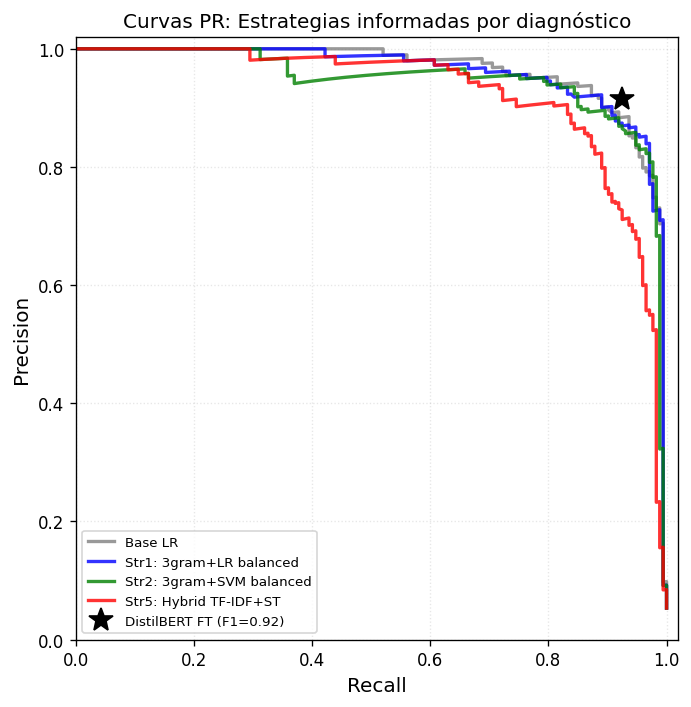

In [22]:
# ============================================================
# CURVAS PR COMPARATIVAS FINALES
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect('equal', adjustable='box')

for name, probs, color in [
    ('Base LR', lr_probs, 'gray'),
    ('Str1: 3gram+LR balanced', lr_v2_probs, 'blue'),
    ('Str2: 3gram+SVM balanced', svm_v2_probs, 'green'),
    ('Str5: Hybrid TF-IDF+ST', hybrid_probs, 'red'),
]:
    p, r, _ = precision_recall_curve(Y_test, probs)
    f1 = f1_score(Y_test, (probs >= 0.5).astype(int))
    ax.plot(r, p, lw=2, label=f'{name}', color=color, alpha=0.8)

# Punto DistilBERT del notebook anterior
ax.plot(0.9249, 0.9143, 'k*', markersize=15, label='DistilBERT FT (F1=0.92)', zorder=5)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curvas PR: Estrategias informadas por diagnóstico', fontsize=12)
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3, linestyle='dotted')
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()